<a href="https://colab.research.google.com/github/pablonvsx/pisi3-ufrpe/blob/main/data-science/notebooks/ML/analise_final/Diagn%C3%B3stico_Temporal_das_Classes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Temporal das Classes de Qualidade da Água

## Objetivo

Foi realizada uma análise temporal da distribuição das classes de qualidade da água ao longo dos anos. O objetivo desta etapa foi investigar possíveis desequilíbrios temporais no conjunto de dados que pudessem impactar a capacidade dos algoritmos em aprender padrões representativos para todas as classes.

Durante os experimentos iniciais, observou-se uma dificuldade recorrente dos modelos em diferenciar amostras classificadas como **Atenção** e **Crítica**, mesmo após a aplicação de técnicas de balanceamento e ajustes de hiperparâmetros. Essa situação levantou a hipótese de que a distribuição das classes poderia variar significativamente ao longo do tempo, fazendo com que determinadas categorias fossem pouco representadas em alguns períodos históricos.

Dessa forma, esta análise busca:

* Investigar a distribuição temporal das classes ao longo dos anos;
* Identificar períodos com maior concentração de registros críticos;
* Avaliar possíveis desequilíbrios temporais entre as categorias;
* Selecionar intervalos temporais mais representativos para os experimentos de Machine Learning;
* Verificar se a concentração ou escassez de determinadas classes pode estar contribuindo para as dificuldades observadas durante a classificação.

Os resultados desta etapa servirão como base para a definição dos recortes temporais utilizados nos experimentos posteriores, contribuindo para uma avaliação mais robusta e consistente dos modelos preditivos.


## Preparação do ambiente

In [2]:
# IMPORT DE BIBLIOTECAS
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import warnings

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
SEED = 42

In [3]:
# DETECÇÃO DE AMBIENTE
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Ambiente Google Colab detectado.")
    drive.mount('/content/drive')
    DATA_PATH = Path(
        "/content/drive/MyDrive/EDA_AquaSense/Dataset/processed/amostra_rotulada.parquet"
    )
else:
    print("Ambiente local/VS Code detectado.")
    DATA_PATH = Path("../../dataset/amostra_rotulada.parquet")

df = pd.read_parquet(DATA_PATH)

print("Dataset Parquet carregado com sucesso.")
print(f"Shape do dataset: {df.shape}")

df.head()

Ambiente Google Colab detectado.
Mounted at /content/drive
Dataset Parquet carregado com sucesso.
Shape do dataset: (141399, 22)


,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),...,CCME_Values,CCME_WQI,ph_ok,od_ok,dbo_ok,nitrate_ok,ammonia_limit,ammonia_ok,environmental_score,conama_status
0,Canada,CZPOH_1117,River,05-03-2012,0.092790,2.25455,9.43636,0.06100,7.50000,9.40000,...,93.116725,Good,1,1,1,1,3.7,1,5,Excelente
1,Canada,FISW_32,Lake,02-12-2003,0.043792,2.13333,9.82400,0.00200,7.79000,12.00000,...,100.000000,Excellent,1,1,1,1,2.0,1,5,Excelente
2,Canada,CZPOH_1036,River,12-03-2018,0.085920,2.01667,11.78333,0.02568,7.36667,8.91667,...,100.000000,Excellent,1,1,1,1,3.7,1,5,Excelente
3,Canada,IEEA_10_32,Lake,08-06-2001,0.015920,0.55000,9.82400,0.00400,7.79000,16.80000,...,100.000000,Excellent,1,1,1,1,2.0,1,5,Excelente
4,Canada,ES0910524,River,11-09-2012,0.150000,2.13333,10.32500,0.07250,7.79000,8.32500,...,92.882835,Good,1,1,1,1,2.0,1,5,Excelente


## Distribuição Temporal das Classes

Nesta seção são apresentadas análises exploratórias da distribuição das classes de qualidade da água ao longo do período monitorado. Serão avaliadas a quantidade de registros por ano, a evolução temporal das categorias e a representatividade de cada classe em diferentes intervalos históricos, permitindo identificar possíveis concentrações ou lacunas que possam influenciar o desempenho dos modelos de classificação.


In [4]:
df["Date"].describe()

,Date
count,141399
unique,13969
top,10-01-2013
freq,56


In [5]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [6]:
df["Date"].dtype

dtype('<M8[ns]')

In [7]:
df.groupby("conama_status")["Date"].agg(["min", "max", "count"])

,min,max,count
conama_status,,,
Atenção,1956-11-16,2023-10-12,9450
Boa,1940-01-03,2023-10-18,27097
Crítica,1970-07-16,2023-07-20,1383
Excelente,1940-02-05,2023-10-23,103469


In [8]:
tabela_ano = pd.crosstab(df["Date"], df["conama_status"])
tabela_ano[tabela_ano["Crítica"] > 0]

conama_status,Atenção,Boa,Crítica,Excelente
Date,,,,
1970-07-16,0,0,1,4
1970-09-15,0,0,1,1
1971-01-05,0,0,1,3
1971-10-01,0,0,1,0
1971-10-15,0,0,1,0
...,...,...,...,...
2022-10-25,0,2,1,17
2022-12-08,0,8,1,12
2023-01-26,0,2,1,14


In [9]:
df["Year"] = df["Date"].dt.year

In [10]:
pd.crosstab(
    df["Year"],
    df["conama_status"]
)

conama_status,Atenção,Boa,Crítica,Excelente
Year,,,,
1940,0,1,0,8
1941,0,0,0,12
1942,0,1,0,12
1943,0,1,0,12
1944,0,1,0,8
...,...,...,...,...
2019,154,921,8,3276
2020,86,598,1,1752
2021,126,692,5,2851


In [11]:
df.groupby("conama_status")["Year"].agg(
    ["min", "max", "count"]
)

,min,max,count
conama_status,,,
Atenção,1956,2023,9450
Boa,1940,2023,27097
Crítica,1970,2023,1383
Excelente,1940,2023,103469


In [12]:
tabela_ano = pd.crosstab(df["Year"], df["conama_status"])

tabela_ano

conama_status,Atenção,Boa,Crítica,Excelente
Year,,,,
1940,0,1,0,8
1941,0,0,0,12
1942,0,1,0,12
1943,0,1,0,12
1944,0,1,0,8
...,...,...,...,...
2019,154,921,8,3276
2020,86,598,1,1752
2021,126,692,5,2851


In [13]:
tabela_prop = pd.crosstab(
    df["Year"],
    df["conama_status"],
    normalize="index"
)

tabela_prop

conama_status,Atenção,Boa,Crítica,Excelente
Year,,,,
1940,0.000000,0.111111,0.000000,0.888889
1941,0.000000,0.000000,0.000000,1.000000
1942,0.000000,0.076923,0.000000,0.923077
1943,0.000000,0.076923,0.000000,0.923077
1944,0.000000,0.111111,0.000000,0.888889
...,...,...,...,...
2019,0.035329,0.211287,0.001835,0.751549
2020,0.035289,0.245384,0.000410,0.718917
2021,0.034295,0.188351,0.001361,0.775993


In [14]:
anos_com_todas_classes = tabela_ano[
    (tabela_ano["Excelente"] > 0) &
    (tabela_ano["Boa"] > 0) &
    (tabela_ano["Atenção"] > 0) &
    (tabela_ano["Crítica"] > 0)
]

anos_com_todas_classes

conama_status,Atenção,Boa,Crítica,Excelente
Year,,,,
1970,2,61,2,214
1971,3,62,4,212
1973,4,61,2,241
1975,8,66,1,252
1976,6,63,1,248
1977,6,48,1,329
1978,2,51,2,235
2000,571,1208,107,4902
2001,656,1048,95,4251


In [19]:
tabela_prop.loc[anos_com_todas_classes.index]

conama_status,Atenção,Boa,Crítica,Excelente
Year,,,,
1970,0.007168,0.218638,0.007168,0.767025
1971,0.010676,0.220641,0.014235,0.754448
1973,0.012987,0.198052,0.006494,0.782468
1975,0.024465,0.201835,0.003058,0.770642
1976,0.018868,0.198113,0.003145,0.779874
1977,0.015625,0.125000,0.002604,0.856771
1978,0.006897,0.175862,0.006897,0.810345
2000,0.084119,0.177961,0.015763,0.722157
2001,0.108430,0.173223,0.015702,0.702645


<Axes: xlabel='Year'>

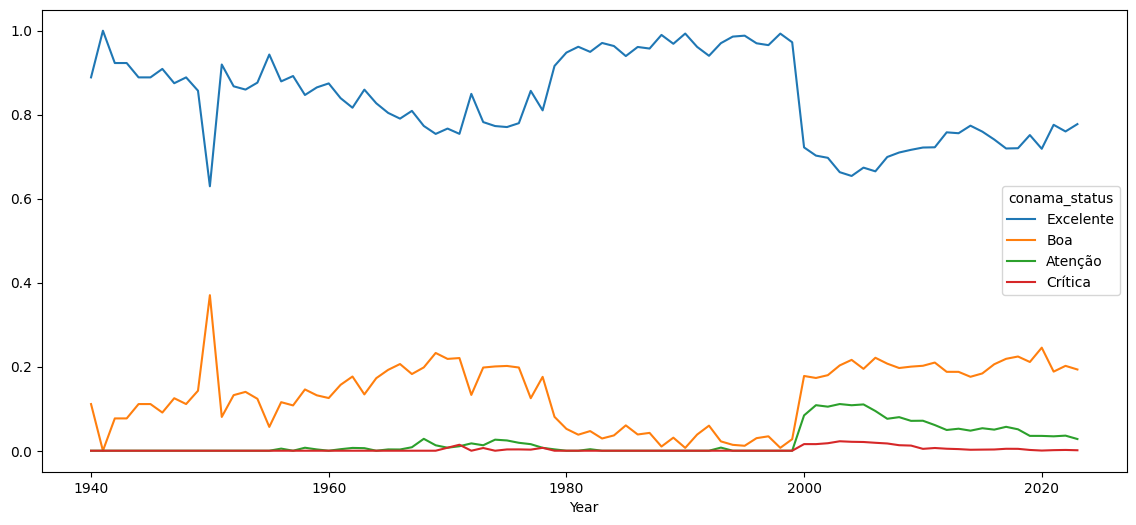

In [20]:
tabela_prop[["Excelente", "Boa", "Atenção", "Crítica"]].plot(
    figsize=(14, 6)
)

In [15]:
df_2000_2023 = df[
    (df["Year"] >= 2000) &
    (df["Year"] <= 2023)
]

df_2000_2023["conama_status"].value_counts()

df_2000_2023["conama_status"].value_counts(normalize=True)

,proportion
conama_status,
Excelente,0.718281
Boa,0.198574
Atenção,0.072549
Crítica,0.010596


In [32]:
df_2000_2008 = df[
    (df["Year"] >= 2000) &
    (df["Year"] <= 2008)
]

df_2000_2008["conama_status"].value_counts()

df_2000_2008["conama_status"].value_counts(normalize=True)

,proportion
conama_status,
Excelente,0.687341
Boa,0.196941
Atenção,0.097536
Crítica,0.018182


In [30]:
df_2000_2008["conama_status"].value_counts()

,count
conama_status,
Excelente,41169
Boa,11796
Atenção,5842
Crítica,1089


>A análise temporal revelou que aproximadamente 98% das amostras classificadas como Crítica estão concentradas entre os anos de 2000 e 2008. Ao restringir o conjunto de dados para esse período, a proporção da classe Crítica aumentou de aproximadamente 0,98% para 1,82%, enquanto grande parte das amostras da classe Excelente foi removida. Esse resultado sugere que a distribuição temporal das classes não é homogênea ao longo da série histórica e pode estar influenciando o processo de aprendizado dos modelos.

## Testes com o intervalo de 2000 até 2008

## Definição de X e y

In [50]:
X = df_2000_2008[[
    "Temperature (cel)",
    "Orthophosphate (mg/l)",
    "Country",
    "Waterbody Type",
    "Nitrogen (mg/l)"
]]

y = df_2000_2008["conama_status"]

In [51]:
# DIVISÃO TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (47916, 5)
Teste: (11980, 5)


In [52]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

conama_status
Excelente    32935
Boa           9437
Atenção       4673
Crítica        871
Name: count, dtype: int64
conama_status
Excelente    0.687349
Boa          0.196949
Atenção      0.097525
Crítica      0.018178
Name: proportion, dtype: float64


In [53]:
# PRÉ-PROCESSAMENTO
categorical_features = [
    "Country",
    "Waterbody Type"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [45]:
# teste 1
class_weights = {
    "Excelente": 1,
    "Boa": 2,
    "Atenção": 4,
    "Crítica": 8
}


In [ ]:
#teste 2
class_weights = {
    "Excelente": 1,
    "Boa": 2,
    "Atenção": 2,
    "Crítica": 8
}


In [46]:
# com balanceamento manual
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                class_weight=class_weights,
                random_state=SEED,
                n_jobs=-1,
                verbose=-1
            )
        )
    ]
)

In [54]:
# com balanceamento automático
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1,
                verbose=-1
            )
        )
    ]
)

In [37]:
# sem balanceamento
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                random_state=SEED,
                n_jobs=-1,
                verbose=-1
            )
        )
    ]
)

In [55]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country',
                                                   'Waterbody Type'])])),
                ('classifier',
                 LGBMClassifier(class_weight='balanced', n_jobs=-1,
                                random_state=42, verbose=-1))])

## Avaliação das Métricas de Treino


In [48]:
# MÉTRICAS DE TREINO balanceamento manual
y_train_pred = model.predict(X_train)

train_accuracy  = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average="weighted")
train_recall    = recall_score(y_train, y_train_pred, average="weighted")
train_f1        = f1_score(y_train, y_train_pred, average="weighted")
train_cm        = confusion_matrix(y_train, y_train_pred)

print("Train Accuracy:")
print(train_accuracy)

print("Train Precision:")
print(train_precision)

print("Train Recall:")
print(train_recall)

print("Train F1:")
print(train_f1)

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

print("Train Confusion Matrix:")
print(train_cm)


Train Accuracy:
0.7282536104850155
Train Precision:
0.7789104454541805
Train Recall:
0.7282536104850155
Train F1:
0.7376756342103622

Classification Report:
              precision    recall  f1-score   support

     Atenção       0.35      0.76      0.48      4673
         Boa       0.62      0.37      0.46      9437
     Crítica       0.34      0.67      0.45       871
   Excelente       0.90      0.83      0.86     32935

    accuracy                           0.73     47916
   macro avg       0.55      0.66      0.56     47916
weighted avg       0.78      0.73      0.74     47916

Train Confusion Matrix:
[[ 3567   350   288   468]
 [ 2855  3461   451  2670]
 [  218    46   582    25]
 [ 3536  1699   415 27285]]


In [56]:
# MÉTRICAS DE TREINO balanceamento automático
y_train_pred = model.predict(X_train)

train_accuracy  = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average="weighted")
train_recall    = recall_score(y_train, y_train_pred, average="weighted")
train_f1        = f1_score(y_train, y_train_pred, average="weighted")
train_cm        = confusion_matrix(y_train, y_train_pred)

print("Train Accuracy:")
print(train_accuracy)

print("Train Precision:")
print(train_precision)

print("Train Recall:")
print(train_recall)

print("Train F1:")
print(train_f1)

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

print("Train Confusion Matrix:")
print(train_cm)


Train Accuracy:
0.6851364888554972
Train Precision:
0.7736571354930071
Train Recall:
0.6851364888554972
Train F1:
0.7150063435846133

Classification Report:
              precision    recall  f1-score   support

     Atenção       0.36      0.62      0.46      4673
         Boa       0.53      0.41      0.46      9437
     Crítica       0.16      0.95      0.27       871
   Excelente       0.92      0.77      0.84     32935

    accuracy                           0.69     47916
   macro avg       0.49      0.68      0.51     47916
weighted avg       0.77      0.69      0.72     47916

Train Confusion Matrix:
[[ 2877   414  1118   264]
 [ 2036  3844  1596  1961]
 [   33     6   824     8]
 [ 2945  3040  1666 25284]]


In [39]:
# MÉTRICAS DE TREINO sem balanceamento
y_train_pred = model.predict(X_train)

train_accuracy  = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average="weighted")
train_recall    = recall_score(y_train, y_train_pred, average="weighted")
train_f1        = f1_score(y_train, y_train_pred, average="weighted")
train_cm        = confusion_matrix(y_train, y_train_pred)

print("Train Accuracy:")
print(train_accuracy)

print("Train Precision:")
print(train_precision)

print("Train Recall:")
print(train_recall)

print("Train F1:")
print(train_f1)

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

print("Train Confusion Matrix:")
print(train_cm)

Train Accuracy:
0.7690333082895067
Train Precision:
0.74754345721799
Train Recall:
0.7690333082895067
Train F1:
0.749183557511634

Classification Report:
              precision    recall  f1-score   support

     Atenção       0.59      0.36      0.45      4673
         Boa       0.58      0.45      0.50      9437
     Crítica       0.66      0.20      0.31       871
   Excelente       0.82      0.93      0.87     32935

    accuracy                           0.77     47916
   macro avg       0.66      0.49      0.53     47916
weighted avg       0.75      0.77      0.75     47916

Train Confusion Matrix:
[[ 1685  1097    23  1868]
 [  565  4229    32  4611]
 [  127   332   173   239]
 [  464  1674    35 30762]]


In [49]:
# MÉTRICAS DE TESTE balanceamento manual
y_pred = model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.6975792988313857

Classification Report:
              precision    recall  f1-score   support

     Atenção       0.30      0.66      0.41      1169
         Boa       0.55      0.31      0.40      2359
     Crítica       0.15      0.28      0.20       218
   Excelente       0.89      0.82      0.85      8234

    accuracy                           0.70     11980
   macro avg       0.47      0.52      0.47     11980
weighted avg       0.75      0.70      0.71     11980


Confusion Matrix:
[[ 776  141  114  138]
 [ 797  738  106  718]
 [ 113   36   60    9]
 [ 926  416  109 6783]]


In [57]:
# MÉTRICAS DE TESTE balanceamento automático
y_pred = model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.6588480801335559

Classification Report:
              precision    recall  f1-score   support

     Atenção       0.30      0.50      0.38      1169
         Boa       0.48      0.36      0.41      2359
     Crítica       0.10      0.62      0.17       218
   Excelente       0.91      0.77      0.83      8234

    accuracy                           0.66     11980
   macro avg       0.45      0.56      0.45     11980
weighted avg       0.75      0.66      0.69     11980


Confusion Matrix:
[[ 590  154  342   83]
 [ 561  838  430  530]
 [  54   24  135    5]
 [ 738  747  419 6330]]


In [40]:
# MÉTRICAS DE TESTE sem balanceamento
y_pred = model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.7327212020033389

Classification Report:
              precision    recall  f1-score   support

     Atenção       0.46      0.28      0.35      1169
         Boa       0.48      0.38      0.42      2359
     Crítica       0.18      0.04      0.06       218
   Excelente       0.80      0.92      0.86      8234

    accuracy                           0.73     11980
   macro avg       0.48      0.40      0.42     11980
weighted avg       0.70      0.73      0.71     11980


Confusion Matrix:
[[ 325  314   18  512]
 [ 203  895   11 1250]
 [  37  105    8   68]
 [ 138  539    7 7550]]


# Conclusões da Análise Temporal

A análise temporal das classes permitiu identificar que a distribuição dos registros críticos não era uniforme ao longo do período histórico disponível. Observou-se que a maior concentração de amostras classificadas como **Crítica** ocorre entre os anos 2000 e 2008, enquanto períodos anteriores e posteriores apresentam quantidades significativamente menores dessa categoria.

Com base nessa observação, foi definido um recorte temporal compreendido entre **2000 e 2008**, buscando aumentar a representatividade das classes minoritárias e fornecer condições mais favoráveis para o treinamento dos modelos de Machine Learning.

Os experimentos realizados nesse novo intervalo demonstraram uma melhora significativa em relação aos resultados obtidos utilizando o conjunto de dados completo. Houve aumento na capacidade dos modelos em identificar amostras das classes minoritárias, especialmente após a aplicação de estratégias de balanceamento manual, além de uma redução dos efeitos causados pela forte concentração da classe **Excelente** observada no dataset original.

Durante os testes foram avaliadas diferentes abordagens:

* Treinamento sem balanceamento;
* Balanceamento automático utilizando `class_weight="balanced"`;
* Balanceamento manual por meio da atribuição de pesos específicos às classes.

Os resultados indicaram que o balanceamento manual apresentou o melhor compromisso entre precisão e recall para as classes minoritárias, enquanto o balanceamento automático elevou excessivamente o recall da classe **Crítica**, reduzindo significativamente sua precisão e aumentando a quantidade de falsos positivos.

Apesar da melhora observada, a análise das matrizes de confusão e dos relatórios de classificação revelou um comportamento consistente entre todos os experimentos: a principal fonte de erro continuou concentrada na distinção entre as classes **Atenção** e **Crítica**.

Mesmo após:

* Ajustes de balanceamento;
* Recorte temporal dos dados;
* Testes com diferentes algoritmos;
* Ajustes de hiperparâmetros;

os modelos continuaram apresentando dificuldade em separar adequadamente essas duas categorias. A maior parte dos erros ocorre quando amostras críticas são classificadas como atenção e vice-versa, indicando uma elevada sobreposição entre os padrões presentes nessas classes.

Análises adicionais realizadas sobre a construção do rótulo mostraram que tanto **Atenção** quanto **Crítica** possuem características ambientais muito semelhantes, diferenciando-se frequentemente pela condição de apenas um parâmetro utilizado na composição do score ambiental. Essa proximidade reduz a capacidade dos modelos em encontrar fronteiras de decisão bem definidas utilizando apenas as variáveis disponíveis para treinamento.

Além disso, o rótulo utilizado foi construído a partir de parâmetros físico-químicos que foram removidos do conjunto de entrada dos modelos para evitar problemas de *data leakage*. Dessa forma, os algoritmos precisaram inferir indiretamente essas condições utilizando variáveis auxiliares, o que aumenta ainda mais a dificuldade de separação entre categorias próximas.

Diante dos resultados obtidos, conclui-se que o recorte temporal de **2000 a 2008** representa uma melhoria importante para os experimentos de classificação, tornando as classes minoritárias mais representativas. Entretanto, os testes também indicam que a dificuldade em distinguir as classes **Atenção** e **Crítica** está associada principalmente à elevada similaridade entre essas categorias e não apenas ao desequilíbrio temporal dos dados.

Essas evidências motivaram a investigação de novas estratégias para redefinição e simplificação do rótulo utilizado nos modelos subsequentes.


## Salvando com o intervalo de 2000 até 2008

In [1]:
df_2000_2008 = df[
    (df["Year"] >= 2000) &
    (df["Year"] <= 2008)
].copy()

NameError: name 'df' is not defined

In [ ]:
print(df_2000_2008.shape)

df_2000_2008["conama_status"].value_counts()

In [ ]:
df_2000_2008.to_parquet(
    "water_quality_2000_2008.parquet",
    index=False
)

In [ ]:
df_2000_2008.to_parquet(
    "/content/drive/MyDrive/EDA_AquaSense/Dataset/processed/water_quality_2000_2008.parquet",
    index=False
)

## Salvando com o intervalo de 2000 até 2023

In [16]:
df_2000_2023 = df[
    (df["Year"] >= 2000) &
    (df["Year"] <= 2023)
].copy()

In [17]:
print(df_2000_2023.shape)

df_2000_2023["conama_status"].value_counts()

(129292, 23)


,count
conama_status,
Excelente,92868
Boa,25674
Atenção,9380
Crítica,1370


In [18]:
df_2000_2023.to_parquet(
    "water_quality_2000_2023.parquet",
    index=False
)

In [20]:
df_2000_2023.to_parquet(
    "/content/drive/MyDrive/EDA_AquaSense/Dataset/processed/water_quality_2000_2023.parquet",
    index=False
)